In [1]:
from rl_opts.virtual_abm import virtual_ABM

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from tqdm.notebook import tqdm

from rl_opts.virtual_abm import get_ABM_motion


from ipywidgets.widgets import Dropdown, IntSlider
from ipywidgets import interact

### Init Functions

In [36]:
def init(L, r, N_eps, time_ep):
    global wrap, phi
    global particle_pos, target_pos, phases, rewards
    global epoch

    gamma = 1e-9
    eta =  0.1

    ### Initiation of RL parameters
    wrap = virtual_ABM(L = L, r = r,
                   num_episodes = N_eps,
                   time_ep = time_ep,
                   gamma_damping = gamma, # This is the learning parameter gamma from PS
                   eta_glow_damping = eta # This is the learning parameter eta from PS
                  )
    
    pBP =  1e-2  # initial probability of changing when passive
    pABP =  1e-4 # initial probability of changing when active
    
    wrap.agent.h_matrix[1, ::2] = pBP / (1-pBP)
    wrap.agent.h_matrix[1, 1::2] = pABP / (1-pABP)
    
    # We first initialize the environmnet. This initializes the epoch counter, sets the
    # the particle and agent in random positions and resents resetting some of the learning parameters
    wrap.init_training()

    # Initial phase of the agent. Note that the agent always starts in the passive phase. 
    phi =  wrap.current_phase
    # If you want to start in the active phase, you just need to set:
    wrap.current_phase = 0

    #Initiating the epoch as a dummy variable
    epoch = wrap.epoch

    # Memory allocation of saving data
    particle_pos = np.zeros((wrap.num_episodes, wrap.time_ep, 2))
    target_pos = np.zeros((wrap.num_episodes, wrap.time_ep, 2))
    phases = np.zeros((wrap.num_episodes, wrap.time_ep))
    rewards = np.zeros((wrap.num_episodes, wrap.time_ep))
    return ('Module Initialized')


In [37]:
D = 0.2 # Diffusion coefficient (mum² s⁻¹)
L = 9.3 # Size of the box (mu) 
tau = L**2 / (4*D) #  Typical time required by a passive particle to cover this distance (s)

Pe = 100 # Péclet number
# v = Pe * L / tau  # self-propulsion velocity
v = 5
dt = 0.150 # Integration time
vdt = v*dt 
ell = 1 # Dimensionless persistence length
D_theta = v/ell  # Rotational diffusion coefficient

sigma = np.sqrt(2*D*dt); # sigma for translational
sigma_theta = np.sqrt(2*D_theta*dt) # sigma for rotational

r = 1 # Size of the target

N_eps = int(1e3)
time_ep = 2000

init(L, r, N_eps, time_ep)

'Module Initialized'

In [38]:
vdt

0.75

### Run Function

In [39]:
def run_episode(first_call, x, y):
    global wrap, phi, epoch
    global particle_pos, target_pos, phases, rewards
    global done

    # for first_call True
    if first_call == 1:
        # First observation
        wrap.env.positions[0] = np.array([x, y])
        # target_position = wrap.env.target_positions[0]
        # start in active phase
        wrap.current_phase = 1
        action = 1

        # set done to false
        done = False
        wrap.done = False  

    else:
        # Saving stuff
        particle_pos[wrap.epoch, wrap.t_ep] = wrap.env.positions[0]
        target_pos[wrap.epoch, wrap.t_ep] = wrap.env.target_positions[0]
        phases[wrap.epoch, wrap.t_ep] = wrap.current_phase
    
        x0, y0 = wrap.env.positions[0].copy()
        # Now we send this to the wrapper. The step function can also give you the reward if asked:
        displacement = (x-x0, y-y0)
        action, reward = wrap.step(displacement, return_reward=True)

        # And let's save the rewards (nothing different than zero to be expected here)
        rewards[wrap.epoch-1, wrap.t_ep-1] = reward # minus ones are needed here because wrap.step already updated the epoch and t_ep
        done = wrap.done
    
    target_position = wrap.env.target_positions[0]
    epoch = wrap.epoch
    return int(action), done, target_position, epoch

In [40]:
# x,y = (np.random.rand(1, 2)*L)[0]
# x0, y0 = wrap.env.positions[0].copy()
theta = 2*np.pi*np.random.rand() 
done = False
for i in tqdm(range(N_eps)):
    x,y = (np.random.rand(1, 2)*L)[0]
    done = False
    first_call = int(True)
    while not done:
        x1, y1, theta = get_ABM_motion(x, y, theta, phi, vdt, sigma, sigma_theta, L)
        # print(wrap.done)
        action, done, target_position, epoch = run_episode(first_call, x1, y1)
        first_call = False
        # print(i, done, wrap.epoch)
        # Update the phase for the ABM generator. This should be the input in the experiment to change phase too.
        if action == 1:
            phi = 1 - phi
        x, y = x1, y1
    if done:
        # Manually initiate the epoch when done
        wrap.init_epoch()

  0%|          | 0/1000 [00:00<?, ?it/s]

### Evaluation and plot

[Text(0, 0.5, '$L = 9.3 \\ \\mu m$')]

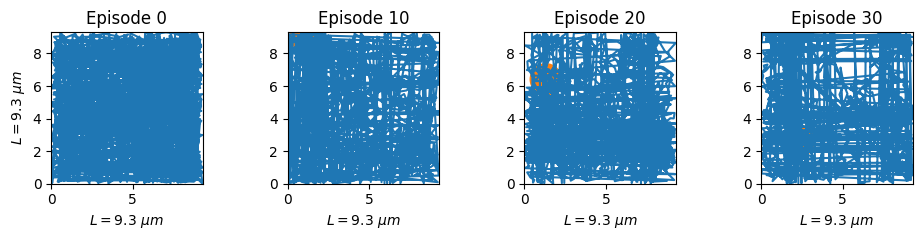

In [41]:
fig, axs = plt.subplots(1, 4, figsize = (4*2.5, 2.5), tight_layout = True)

episodes_vis = [0, 10, 20, 30] # The episodes we will visualize

for ax, ep in zip(axs, episodes_vis):
    ax.plot(particle_pos[ep,:,0], particle_pos[ep,:,1])
    
    # Visualizing the target. Note that here I considered that there were not encounters,
    # so there was no relocation of the target withing an episode. This won't be true when
    # we do proper trainings
    circle = patches.Circle((target_pos[ep,0,0],target_pos[ep,0,1]), radius=r, facecolor='C1')
    ax.add_patch(circle)
    
    ax.set_title(f'Episode {ep}')
    
plt.setp(axs, xlim = (0, L), ylim = (0, L), xlabel = fr'$L = {L} \ \mu m$', aspect = 'equal');
plt.setp(axs[0], ylabel = fr'$L = {L} \ \mu m$')

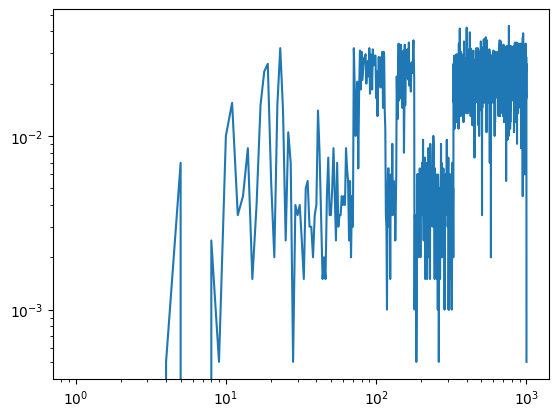

In [42]:
plt.loglog(np.linspace(1, N_eps, N_eps), rewards.mean(axis=1))

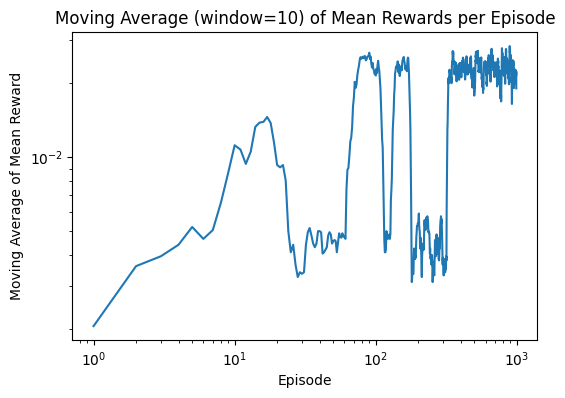

In [43]:
window = 10  # moving average window size
mean_rewards = rewards.mean(axis=1)
moving_avg = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(6, 4))
plt.loglog(np.arange(1, len(moving_avg)+1), moving_avg)
plt.xlabel('Episode')
plt.ylabel('Moving Average of Mean Reward')
plt.title(f'Moving Average (window={window}) of Mean Rewards per Episode')
plt.show()

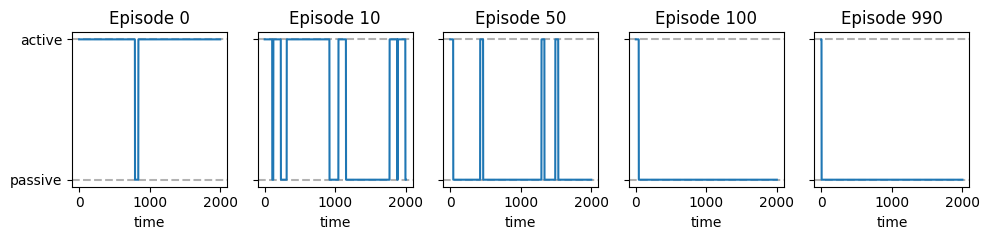

In [44]:
fig, axs = plt.subplots(1, 5, figsize = (4*2.5, 2.5), tight_layout = True)
episodes_vis = [0, 10, 50, 100, 990] # The episodes we will visualize

for ax, ep in zip(axs, episodes_vis):    
    ax.plot(np.arange(wrap.time_ep), phases[ep, :], zorder = 10)
    ax.set_title(f'Episode {ep}')

    ax.axhline(0, c = 'k', ls = '--', alpha = 0.3)
    ax.axhline(1, c = 'k', ls = '--', alpha = 0.3)
    
plt.setp(axs, xlabel = 'time', yticks = [0,1], yticklabels = []);
plt.setp(axs[0], yticklabels = ['passive', 'active']);

In [ ]:
def plot_ep(ep):

    colors1 = [plt.cm.viridis(k) for k in np.linspace(0,1,particle_pos[ep].shape[0])]
    xv1 = particle_pos[ep,:,0]
    yv1 = particle_pos[ep,:,1]
    # for k1 in range(particle_pos[ep].shape[0]):
    #     xv1.append(particle_pos[ep,:,0])
    #     yv1.append(coords1[k1][1])
    


    plt.figure(figsize=(10,4))
    plt.subplot(121)
    # plt.plot(particle_pos[ep,:,0], particle_pos[ep,:,1])
    for k1 in range(particle_pos[ep].shape[0]):
        plt.plot(xv1[k1:k1+2], yv1[k1:k1+2], color=colors1[k1], alpha = 0.6, lw = 1.5)

    circle = patches.Circle((target_pos[ep,0,0],target_pos[ep,0,1]), radius=r, facecolor='C1')
    plt.gca().add_patch(circle)
    plt.axis('square')
    plt.setp(plt.gca(), xlim = (0, L), ylim = (0, L), xlabel = fr'$L = {L} \ \mu m$', aspect = 'equal');
    plt.setp(plt.gca(), ylabel = fr'$L = {L} \ \mu m$')
    
    plt.subplot(122)
    plt.plot(np.arange(wrap.time_ep), phases[ep, :], zorder = 10, alpha = 0.5)
    plt.plot(np.arange(wrap.time_ep), rewards[ep, :], zorder = 10, alpha = 0.5)
    plt.gca().set_title(f'Episode {ep}')
    plt.axhline(0, c = 'k', ls = '--', alpha = 0.3)
    plt.axhline(1, c = 'k', ls = '--', alpha = 0.3)
    plt.setp(plt.gca(), xlabel = 'time', yticks = [0,1], yticklabels = []);
    plt.setp(plt.gca(), yticklabels = ['passive', 'active']);

interact(plot_ep, ep =IntSlider(min=0, max = N_eps-1, step = 1))

interactive(children=(IntSlider(value=0, description='ep', max=999), Output()), _dom_classes=('widget-interact…

<function __main__.plot_ep(ep)>

### Grid Search

In [32]:
pBP =  1e-2  # initial probability of changing when passive
pABP =  1e-4 # initial probability of changing when active

def train_loop_abm(gamma, eta):

    wrap = virtual_ABM(L = L, r = r,
                    num_episodes = None,
                    time_ep = 2000,
                    gamma_damping = gamma, 
                    eta_glow_damping = eta 
                    ) 
                        

    wrap.agent.h_matrix[1, ::2] = pBP / (1-pBP)
    wrap.agent.h_matrix[1, 1::2] = pABP / (1-pABP)

    wrap.init_training()
    

    # Let's save the position of the agent and targets at each time step and each episode, as well as its phase and rewards 
    # particle_pos = np.zeros((N_episodes, wrap.time_ep, 2))
    # target_pos = np.zeros((N_episodes, wrap.time_ep, 2))
    # phases = np.zeros((N_episodes, wrap.time_ep))
    rewards = np.zeros((N_eps, wrap.time_ep))
    # hmats = np.zeros((wrap.num_episodes, wrap.agent.h_matrix.shape[0], wrap.agent.h_matrix.shape[1]))

    for epoch in range(N_eps):

        wrap.init_virtual_env()

        # hmats[epoch] = wrap.agent.h_matrix.copy()

        # Initial phase of the agent. Note that the agent always starts in the passive phase. 
        phi =  wrap.current_phase
        # If you want to start in the active phase, you just need to set:
        wrap.current_phase = np.random.randint(2)  # This will randomly set the phase to either 0 or 1, but we start in passive phase
        # at the start of the code.
        
        # We set a random initial direction for the ABM generator
        theta = 2*np.pi*np.random.rand()     


        for t in range(wrap.time_ep):

            # Saving stuff
            # particle_pos[epoch, t] = wrap.env.positions[0]
            # target_pos[epoch, t] = wrap.env.target_positions[0]
            # phases[epoch, t] = wrap.current_phase

            # Generating displacement via ABM
            x0, y0 = wrap.env.positions[0].copy()
            x1, y1, theta = get_ABM_motion(x0, y0, theta, phi, vdt, sigma, sigma_theta, L)

            # Now we send this to the wrapper. The step function can also give you the reward if asked:
            displacement = (x1-x0, y1-y0)
            action, reward = wrap.step(displacement, return_reward=True)

            # Update the phase for the ABM generator. This should be the input in the experiment to change phase too.
            if action == 1:
                phi = 1 - phi

            # And let's save the rewards (nothing different than zero to be expected here)
            rewards[epoch, t] = reward # minus ones are needed here because wrap.step already updated the epoch and t_ep


    return rewards, wrap.agent.h_matrix

    

In [33]:
gammas = np.logspace(-9,-3,12)
etas = np.logspace(-4,-0,12)

N_episodes = int(1e3)


rewards = np.zeros((gammas.shape[0], etas.shape[0], N_episodes))
for idxg, gamma in tqdm(enumerate(gammas)):
    for idxe, eta in enumerate(etas):
        rews, _ = train_loop_abm(gamma, eta)

        rewards[idxg, idxe] = rews.mean(1)     



0it [00:00, ?it/s]

In [34]:
gammas

array([1.00000000e-09, 3.51119173e-09, 1.23284674e-08, 4.32876128e-08,
       1.51991108e-07, 5.33669923e-07, 1.87381742e-06, 6.57933225e-06,
       2.31012970e-05, 8.11130831e-05, 2.84803587e-04, 1.00000000e-03])

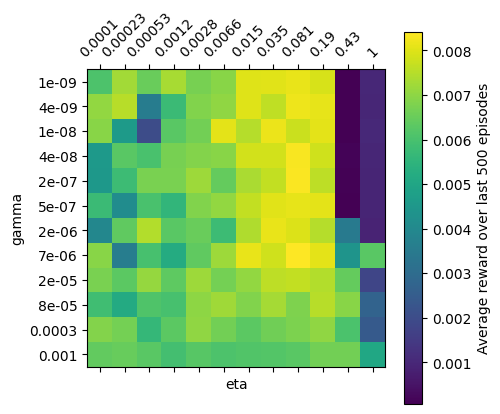

In [35]:
plt.matshow(rewards[:,:,-500:].mean(-1))

plt.xlabel('eta')
plt.ylabel('gamma')
plt.xticks(ticks=np.arange(len(etas)), labels=[f"{e:.2g}" for e in etas], rotation=45)
plt.yticks(ticks=np.arange(len(gammas)), labels=[f"{g:.1g}" for g in gammas])
plt.colorbar(label ='Average reward over last 500 episodes')